# Phân tích RFM và Phân cụm Khách hàng bằng Agglomerative Hierarchical Clustering

**Demo bảo vệ khóa luận tốt nghiệp**

Notebook này triển khai toàn bộ quy trình: tiền xử lý dữ liệu, xây dựng đặc trưng RFM, chuẩn hóa Z-score, phân cụm phân cấp (Ward linkage), đánh giá chất lượng phân cụm (Dendrogram, Silhouette Score), và trực quan hóa 3D tương tác bằng Plotly.

## 1. Giới thiệu

Phân khúc khách hàng là quá trình nhóm người mua theo hành vi giao dịch, từ đó xây dựng chiến lược marketing phù hợp. Dự án kết hợp hai phương pháp:

| Phương pháp | Mục đích |
|---|---|
| **RFM Analysis** | Đo lường từng khách hàng qua 3 chỉ số: Recency (ngày kể từ lần mua gần nhất), Frequency (số lần đặt hàng), Monetary (tổng chi tiêu) |
| **Agglomerative Hierarchical Clustering** | Phương pháp phân cụm "từ dưới lên", dần hợp nhất các khách hàng gần nhất theo Ward linkage và Euclidean distance |

Số cụm tối ưu *k* = 4 được xác nhận qua Dendrogram và Silhouette Score. Bốn phân khúc kết quả: **VIP Customers**, **Loyal Customers**, **New Customers**, **Lost Customers** — dựa trên đặc điểm RFM trung bình của từng nhóm.

**Dataset:** UCI Online Retail II (~500.000 giao dịch thực tế, hơn 10.000 khách hàng).

## 2. Tải bộ dữ liệu Online Retail

Load file `.csv` hoặc `.xlsx` trong thư mục dự án

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import plotly.express as px
import os

_notebook_dir = os.getcwd()

# =========================================================
# CÁC THƯ MỤC CÓ THỂ CHỨA DATASET
# =========================================================

_search_dirs = [
    os.path.join(_notebook_dir, "data"),   # notebooks/data
    _notebook_dir                          # thư mục notebook hiện tại
]

# =========================================================
# CÁC TÊN FILE DATASET ĐƯỢC HỖ TRỢ
# =========================================================

_data_names = [
    "online_retail.xlsx",
    "online_retail.csv",
]

_df_path = None

for d in _search_dirs:

    # Bỏ qua nếu thư mục không tồn tại
    if not os.path.isdir(d):
        continue

    # Duyệt qua từng tên file dataset
    for name in _data_names:

        candidate = os.path.join(d, name)

        print(f"[CHECK] {candidate}")

        # Nếu tìm thấy file thì lưu đường dẫn
        if os.path.isfile(candidate):
            _df_path = candidate
            break

    # Dừng vòng lặp nếu đã tìm thấy dataset
    if _df_path:
        break

if _df_path is None:
    raise FileNotFoundError(
        "Dataset not found.\n"
        "Please place:\n"
        " - online_retail.xlsx\n"
        "or\n"
        " - online_retail.csv\n"
        "inside:\n"
        " - notebooks/data/\n"
        "or current notebook folder."
    )

# =========================================================
# LOAD DATASET
# =========================================================

print(f"\n[OK] Found dataset:")
print(_df_path)

# Lấy phần mở rộng của file
ext = os.path.splitext(_df_path)[1].lower()

if ext == ".csv":

    df = pd.read_csv(
        _df_path,
        encoding="latin-1",
        parse_dates=["InvoiceDate"]
    )

elif ext == ".xlsx":

    df = pd.read_excel(
        _df_path,
        engine="openpyxl",
        parse_dates=["InvoiceDate"]
    )

else:
    raise ValueError(f"Unsupported file format: {ext}")

print(f"[OK] Loaded {len(df):,} rows")

# =========================================================
# CHUẨN HÓA TÊN CỘT DỮ LIỆU
# =========================================================

_col_map = {}

for _c in df.columns:

    # Xóa khoảng trắng và chuyển thành chữ thường
    _cl = _c.strip().lower()

    # Chuẩn hóa cột số lượng
    if _cl in ("quantity", "qty"):
        _col_map[_c] = "Quantity"

    # Chuẩn hóa cột đơn giá
    elif _cl in ("unitprice", "unit_price"):
        _col_map[_c] = "UnitPrice"

    # Chuẩn hóa cột mã khách hàng
    elif _cl in ("customerid", "customer_id"):
        _col_map[_c] = "CustomerID"

    # Chuẩn hóa cột ngày giao dịch
    elif _cl in ("invoicedate", "invoice_date"):
        _col_map[_c] = "InvoiceDate"

    # Chuẩn hóa cột mã hóa đơn
    elif _cl in ("invoiceno", "invoice_no"):
        _col_map[_c] = "InvoiceNo"

# Đổi tên cột nếu có mapping
if _col_map:
    df = df.rename(columns=_col_map)

# =========================================================
# HIỂN THỊ THÔNG TIN DATASET
# =========================================================

print(f"\nDataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

print("\nColumns:")
print(list(df.columns))

# Hiển thị 5 dòng đầu tiên
df.head(5)


[CHECK] C:\Users\THANH TRUNG\Desktop\Work\Hierarchical_Clustering\notebooks\data\online_retail.xlsx

[OK] Found dataset:
C:\Users\THANH TRUNG\Desktop\Work\Hierarchical_Clustering\notebooks\data\online_retail.xlsx
[OK] Loaded 541,909 rows

Dataset shape: 541,909 rows x 8 columns

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Tiền xử lý dữ liệu

Dữ liệu giao dịch thô chứa các bản ghi không hợp lệ. Áp dụng 5 quy tắc làm sạch:

1. **Loại hóa đơn đã hủy** — InvoiceNo bắt đầu bằng "C" (credit note / hoàn hàng)
2. **Loại thiếu CustomerID** — giao dịch không thể gán cho khách hàng nào
3. **Loại Quantity ≤ 0** — nhập sai hoặc hoàn trả
4. **Loại UnitPrice ≤ 0** — giá âm / miễn phí làm lệch tính toán
5. **Loại trùng lặp** — tránh tính đếm tần suất và doanh thu quá cao

Sau khi làm sạch, tính `TotalAmount = Quantity × UnitPrice` cho mỗi dòng giao dịch.

In [2]:
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)
print(f"Rows before cleaning : {len(df):,}")

# Lưu lại số dòng ban đầu để tính số dòng bị loại bỏ
original = len(df)

# =========================================================
# 1. LOẠI BỎ ĐƠN HÀNG HỦY / TRẢ HÀNG
# InvoiceNo bắt đầu bằng chữ "C" thường là đơn bị hủy
# =========================================================

if "InvoiceNo" in df.columns:
    before = len(df)

    df = df[
        ~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")
    ].copy()

    print(f"  After removing cancellations : {len(df):,}  (removed {before - len(df):,})")

# =========================================================
# 2. LOẠI BỎ DÒNG KHÔNG CÓ MÃ KHÁCH HÀNG
# Vì RFM cần CustomerID để gom giao dịch theo từng khách hàng
# =========================================================

before = len(df)

df.dropna(subset=["CustomerID"], inplace=True)
df = df[df["CustomerID"].astype(str) != "nan"].copy()
df = df[df["CustomerID"].astype(str).str.strip() != ""].copy()

print(f"  After removing missing CustomerID: {len(df):,}  (removed {before - len(df):,})")

# =========================================================
# 3. LOẠI BỎ SỐ LƯỢNG KHÔNG HỢP LỆ
# Quantity <= 0 không phản ánh giao dịch mua hàng hợp lệ
# =========================================================

before = len(df)

df = df[
    pd.to_numeric(df["Quantity"], errors="coerce") > 0
].copy()

print(f"  After removing Quantity <= 0     : {len(df):,}  (removed {before - len(df):,})")

# =========================================================
# 4. LOẠI BỎ ĐƠN GIÁ KHÔNG HỢP LỆ
# UnitPrice <= 0 có thể là lỗi dữ liệu hoặc giao dịch không có giá trị mua hàng
# =========================================================

before = len(df)

df = df[
    pd.to_numeric(df["UnitPrice"], errors="coerce") > 0
].copy()

print(f"  After removing UnitPrice <= 0    : {len(df):,}  (removed {before - len(df):,})")

# =========================================================
# 5. LOẠI BỎ DỮ LIỆU TRÙNG LẶP
# Tránh một giao dịch bị tính nhiều lần trong quá trình phân tích
# =========================================================

before = len(df)

dedup_cols = ["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"]

if "InvoiceNo" in df.columns:
    dedup_cols = ["CustomerID", "InvoiceNo"] + dedup_cols

df = df.drop_duplicates(subset=dedup_cols)

print(f"  After removing duplicates        : {len(df):,}  (removed {before - len(df):,})")

# =========================================================
# 6. TÍNH GIÁ TRỊ GIAO DỊCH
# TotalAmount = Quantity * UnitPrice
# Đây là cơ sở để tính Monetary trong RFM
# =========================================================

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

df["TotalAmount"] = (
    df["Quantity"] * df["UnitPrice"]
).round(2)

# =========================================================
# THỐNG KÊ SAU KHI LÀM SẠCH DỮ LIỆU
# =========================================================

removed = original - len(df)

print("")
print(f"Rows after cleaning   : {len(df):,}")
print(f"Total removed         : {removed:,} ({removed / original * 100:.1f}%)")
print(f"Unique customers      : {df['CustomerID'].nunique():,}")
print("=" * 60)

DATA PREPROCESSING
Rows before cleaning : 541,909
  After removing cancellations : 532,621  (removed 9,288)
  After removing missing CustomerID: 397,924  (removed 134,697)
  After removing Quantity <= 0     : 397,924  (removed 0)
  After removing UnitPrice <= 0    : 397,884  (removed 40)
  After removing duplicates        : 247,427  (removed 150,457)

Rows after cleaning   : 247,427
Total removed         : 294,482 (54.3%)
Unique customers      : 4,338


## 4. Xây dựng đặc trưng RFM

Từ dữ liệu đã làm sạch, tính 3 chỉ số cho từng khách hàng:

- **Recency** — số ngày từ lần mua cuối đến ngày phân tích. Giá trị càng thấp → khách hàng càng hoạt động gần đây.
- **Frequency** — số hóa đơn riêng biệt. Giá trị càng cao → mức độ tái mua cao.
- **Monetary** — tổng chi tiêu (`Σ Quantity × UnitPrice`). Giá trị càng cao → giá trị khách hàng càng lớn.

Ba đặc trưng này là đầu vào của thuật toán phân cụm.

In [3]:
# =========================================================
# TÍNH NGÀY PHÂN TÍCH
# =========================================================
# Ngày phân tích được lấy bằng ngày giao dịch cuối cùng + 1 ngày
# Cách này giúp Recency luôn >= 0

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# =========================================================
# TÍNH BẢNG RFM THEO TỪNG KHÁCH HÀNG
# =========================================================
# Recency  : số ngày kể từ lần mua gần nhất
# Frequency: số lần mua hàng / số hóa đơn
# Monetary : tổng số tiền khách hàng đã chi

if "InvoiceNo" in df.columns:

    rfm = df.groupby("CustomerID").agg(

        # Tính khoảng cách từ ngày phân tích đến lần mua gần nhất
        recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),

        # Đếm số hóa đơn khác nhau của từng khách hàng
        frequency=("InvoiceNo", "nunique"),

        # Tính tổng giá trị mua hàng của từng khách hàng
        monetary=("TotalAmount", "sum"),

    ).reset_index()

else:

    rfm = df.groupby("CustomerID").agg(

        # Tính số ngày từ lần mua gần nhất đến ngày phân tích
        recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),

        # Nếu không có InvoiceNo thì dùng số dòng giao dịch để tính Frequency
        frequency=("InvoiceDate", "count"),

        # Tổng số tiền khách hàng đã chi
        monetary=("TotalAmount", "sum"),

    ).reset_index()

# Làm tròn giá trị Monetary đến 2 chữ số thập phân
rfm["monetary"] = rfm["monetary"].round(2)

# Sắp xếp khách hàng theo tổng chi tiêu giảm dần
rfm = rfm.sort_values("monetary", ascending=False).reset_index(drop=True)

# =========================================================
# HIỂN THỊ KẾT QUẢ RFM
# =========================================================

print(f"RFM table     : {rfm.shape[0]:,} customers x {rfm.shape[1]} features")
print(f"Analysis date : {analysis_date.date()}")
print(f"Top 5 customers by monetary value:")

# Hiển thị 5 khách hàng có giá trị Monetary cao nhất
rfm.head(5)

RFM table     : 4,338 customers x 4 features
Analysis date : 2011-12-10
Top 5 customers by monetary value:


,CustomerID,recency,frequency,monetary
0,14646.0,2,73,202359.83
1,18102.0,1,60,173369.02
2,17450.0,8,46,168503.41
3,16446.0,1,2,168472.50
4,14911.0,1,201,104034.40


In [4]:
# =========================================================
# TRỰC QUAN HÓA PHÂN PHỐI CỦA CÁC THUỘC TÍNH RFM
# =========================================================
# Biểu đồ histogram giúp quan sát:
# - dữ liệu phân bố như thế nào
# - có bị lệch hay không
# - có xuất hiện outlier hay không

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Duyệt qua từng thuộc tính RFM
for ax, col, label in zip(
    axes,
    ["recency", "frequency", "monetary"],
    ["Recency (days)", "Frequency (orders)", "Monetary ($)"]
):

    # Vẽ histogram
    ax.hist(
        rfm[col],
        bins=30,
        color="#6366f1",
        edgecolor="white",
        alpha=0.85
    )

    # Tiêu đề biểu đồ
    ax.set_title(
        label,
        fontsize=12,
        fontweight="bold"
    )

    # Ẩn tên trục X để giao diện gọn hơn
    ax.set_xlabel("")

    # Chỉ hiển thị tên trục Y ở biểu đồ đầu tiên
    ax.set_ylabel(
        "Customers" if ax is axes[0] else ""
    )

    # Vẽ đường trung bình (mean)
    ax.axvline(
        rfm[col].mean(),
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"Mean = {rfm[col].mean():.1f}"
    )

    # Hiển thị chú thích mean
    ax.legend(fontsize=9)

# Tự động căn chỉnh layout
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# =========================================================
# THỐNG KÊ GIÁ TRỊ MIN / MAX / MEAN
# =========================================================

print(
    f"Recency   : "
    f"min={rfm['recency'].min()}, "
    f"max={rfm['recency'].max()}, "
    f"mean={rfm['recency'].mean():.1f}"
)

print(
    f"Frequency : "
    f"min={rfm['frequency'].min()}, "
    f"max={rfm['frequency'].max()}, "
    f"mean={rfm['frequency'].mean():.1f}"
)

print(
    f"Monetary  : "
    f"min={rfm['monetary'].min():.2f}, "
    f"max={rfm['monetary'].max():.2f}, "
    f"mean={rfm['monetary'].mean():.2f}"
)

Recency   : min=1, max=374, mean=92.5
Frequency : min=1, max=209, mean=4.3
Monetary  : min=3.75, max=202359.83, mean=1533.85


In [ ]:
%%sql


## 5. Chuẩn hóa Z-score

Ba đặc trưng RFM có thang đo rất khác nhau: Recency (hàng trăm ngày), Frequency (số đơn hàng), Monetary (mức tiền). Thuật toán phân cụm dựa trên khoảng cách nhạy cảm với thang đo — nếu không chuẩn hóa, đặc trưng có giá trị lớn nhất sẽ chi phối kết quả.

Z-score standardization đưa mỗi đặc trưng về mean = 0, std = 1:

    z = (x - mean) / std

Sau biến đổi, mỗi chiều RFM đóng góp như nhau vào tính toán Euclidean distance.

In [5]:
# =========================================================
# CHUẨN HÓA DỮ LIỆU RFM BẰNG STANDARD SCALER
# =========================================================
# Mục tiêu:
# - Đưa các đặc trưng về cùng thang đo
# - Tránh thuộc tính có giá trị lớn chi phối quá trình clustering
#
# Ví dụ:
# - Monetary có thể lên tới hàng nghìn
# - Frequency chỉ vài chục
# => Nếu không chuẩn hóa, mô hình sẽ ưu tiên Monetary

from sklearn.preprocessing import StandardScaler

# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# =========================================================
# THỰC HIỆN CHUẨN HÓA Z-SCORE
# =========================================================
# Công thức:
#
# z = (x - mean) / std
#
# Sau chuẩn hóa:
# - Mean xấp xỉ 0
# - Standard deviation xấp xỉ 1

rfm_scaled = scaler.fit_transform(
    rfm[["recency", "frequency", "monetary"]]
)

# =========================================================
# CHUYỂN KẾT QUẢ THÀNH DATAFRAME
# =========================================================
# Tạo bảng dữ liệu mới để dễ quan sát

scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=[
        "recency_z",
        "frequency_z",
        "monetary_z"
    ]
)

# =========================================================
# THỐNG KÊ TRƯỚC KHI CHUẨN HÓA
# =========================================================

print("Before standardization:")

print(
    rfm[
        ["recency", "frequency", "monetary"]
    ]
    .describe()
    .loc[["mean", "std"]]
    .round(2)
)

print()

# =========================================================
# THỐNG KÊ SAU KHI CHUẨN HÓA
# =========================================================
# Kỳ vọng:
# - mean ≈ 0
# - std ≈ 1

print("After standardization (mean ~ 0, std ~ 1):")

print(
    scaled_df
    .describe()
    .loc[["mean", "std"]]
    .round(4)
)

Before standardization:
      recency  frequency  monetary
mean    92.54       4.27   1533.85
std    100.01       7.70   6988.43

After standardization (mean ~ 0, std ~ 1):
      recency_z  frequency_z  monetary_z
mean     0.0000       0.0000      0.0000
std      1.0001       1.0001      1.0001


## 6. Agglomerative Hierarchical Clustering (Ward Linkage)

Phương pháp phân cụm phân cấp tích tụ ("từ dưới lên") bắt đầu từ việc coi mỗi khách hàng là một cụm riêng biệt, sau đó hợp nhất dần các cặp cụm gần nhất để tạo nên cấu trúc phân cấp.

**Ward linkage** — tiêu chí hợp nhất: từng bước gộp hai cụm làm tăng phương sai nội cụm nhỏ nhất. Phương pháp này tạo ra các cụm compact và có kích thước tương đồng — phù hợp cho phân khúc khách hàng.

Khoảng cách giữa các điểm được tính bằng **Euclidean distance** trên không gian đặc trưng RFM đã chuẩn hóa.

Phân cụm được thực hiện trên **toàn bộ** tập khách hàng RFM, không lấy mẫu.

→ Số cụm tối ưu sẽ được xác định thông qua Dendrogram ở phần tiếp theo.

In [6]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 4

model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward",
)

# IMPORTANT: Clustering runs on the FULL standardized RFM data (all customers)
rfm["cluster"] = model.fit_predict(rfm_scaled)

print(f"Clustering complete: {rfm['cluster'].nunique()} clusters "
      f"assigned to {len(rfm):,} customers")
print()
print("Cluster sizes:")
for k in sorted(rfm["cluster"].unique()):
    cnt = (rfm["cluster"] == k).sum()
    print(f"  Cluster {k}: {cnt:>6,} customers ({cnt / len(rfm) * 100:>5.1f}%)")

Clustering complete: 4 clusters assigned to 4,338 customers

Cluster sizes:
  Cluster 0:     20 customers (  0.5%)
  Cluster 1:  3,228 customers ( 74.4%)
  Cluster 2:    946 customers ( 21.8%)
  Cluster 3:    144 customers (  3.3%)


## 7. Phân tích Dendrogram để chọn số cụm

Dendrogram là biểu đồ cây ghi lại toàn bộ quá trình hợp nhất các cụm trong phân cụm phân cấp. Trục tung thể hiện **Euclidean distance** tại mỗi lần gộp.

**Cách đọc:**
- Đoạn thẳng đứng càng dài → khoảng cách giữa hai cụm càng lớn → phân tách tự nhiên rõ.
- Đường cắt ngang giúp xác định số cụm hợp lý — vị trí cắt qua các đoạn thẳng đứng dài nhất.

Khi quan sát dendrogram, đường cắt tại vị trí có khoảng cách lớn tạo ra **4 cụm tự nhiên**, tương ứng với các nhóm khách hàng phổ biến trong marketing (VIP, Loyal, New, Lost).

→ Vì vậy, mô hình chọn **k = 4** cho bước phân cụm cuối cùng.

*Dendrogram được vẽ trên mẫu 500 khách hàng để dễ quan sát. Phân cụm thực tế chạy trên toàn bộ dữ liệu RFM.*

In [16]:
# =========================================================
# THỰC HIỆN PHÂN CỤM KHÁCH HÀNG
# BẰNG HIERARCHICAL CLUSTERING
# =========================================================

from sklearn.cluster import AgglomerativeClustering

# =========================================================
# THIẾT LẬP SỐ CỤM
# =========================================================
# Chọn 4 cụm dựa trên:
# - Dendrogram
# - Phân tích hành vi khách hàng
# - Mục tiêu business segmentation

n_clusters = 4

# =========================================================
# KHỞI TẠO MÔ HÌNH AGGLOMERATIVE CLUSTERING
# =========================================================
# Agglomerative = gom cụm từ dưới lên
#
# Ban đầu:
# - mỗi khách hàng là 1 cụm riêng
#
# Sau đó:
# - hệ thống liên tục gộp các cụm gần nhau nhất
# - cho đến khi còn đúng 4 cụm

model = AgglomerativeClustering(

    # Số cụm cuối cùng cần tạo
    n_clusters=n_clusters,

    # Ward linkage:
    # chọn cách gộp cụm làm tăng phương sai ít nhất
    linkage="ward",
)

# =========================================================
# CHẠY PHÂN CỤM TRÊN TOÀN BỘ DỮ LIỆU RFM
# =========================================================
# Lưu ý:
# - Dữ liệu đầu vào là RFM đã standardize
# - Clustering chạy trên FULL dataset
# - Không chỉ chạy trên sample của dendrogram

rfm["cluster"] = model.fit_predict(rfm_scaled)

# =========================================================
# HIỂN THỊ KẾT QUẢ PHÂN CỤM
# =========================================================

print(
    f"Clustering complete: "
    f"{rfm['cluster'].nunique()} clusters "
    f"assigned to {len(rfm):,} customers"
)

print()
print("Cluster sizes:")

# =========================================================
# THỐNG KÊ SỐ KHÁCH HÀNG TRONG TỪNG CỤM
# =========================================================

for k in sorted(rfm["cluster"].unique()):

    # Đếm số khách hàng thuộc cluster k
    cnt = (rfm["cluster"] == k).sum()

    # In số lượng và tỷ lệ %
    print(
        f"  Cluster {k}: "
        f"{cnt:>6,} customers "
        f"({cnt / len(rfm) * 100:>5.1f}%)"
    )

Clustering complete: 4 clusters assigned to 4,338 customers

Cluster sizes:
  Cluster 0:     20 customers (  0.5%)
  Cluster 1:  3,228 customers ( 74.4%)
  Cluster 2:    946 customers ( 21.8%)
  Cluster 3:    144 customers (  3.3%)


Dendrogram sample size : 500 customers
Full clustering dataset: 4,338 customers
Cut height for 4 clusters: 16.0575


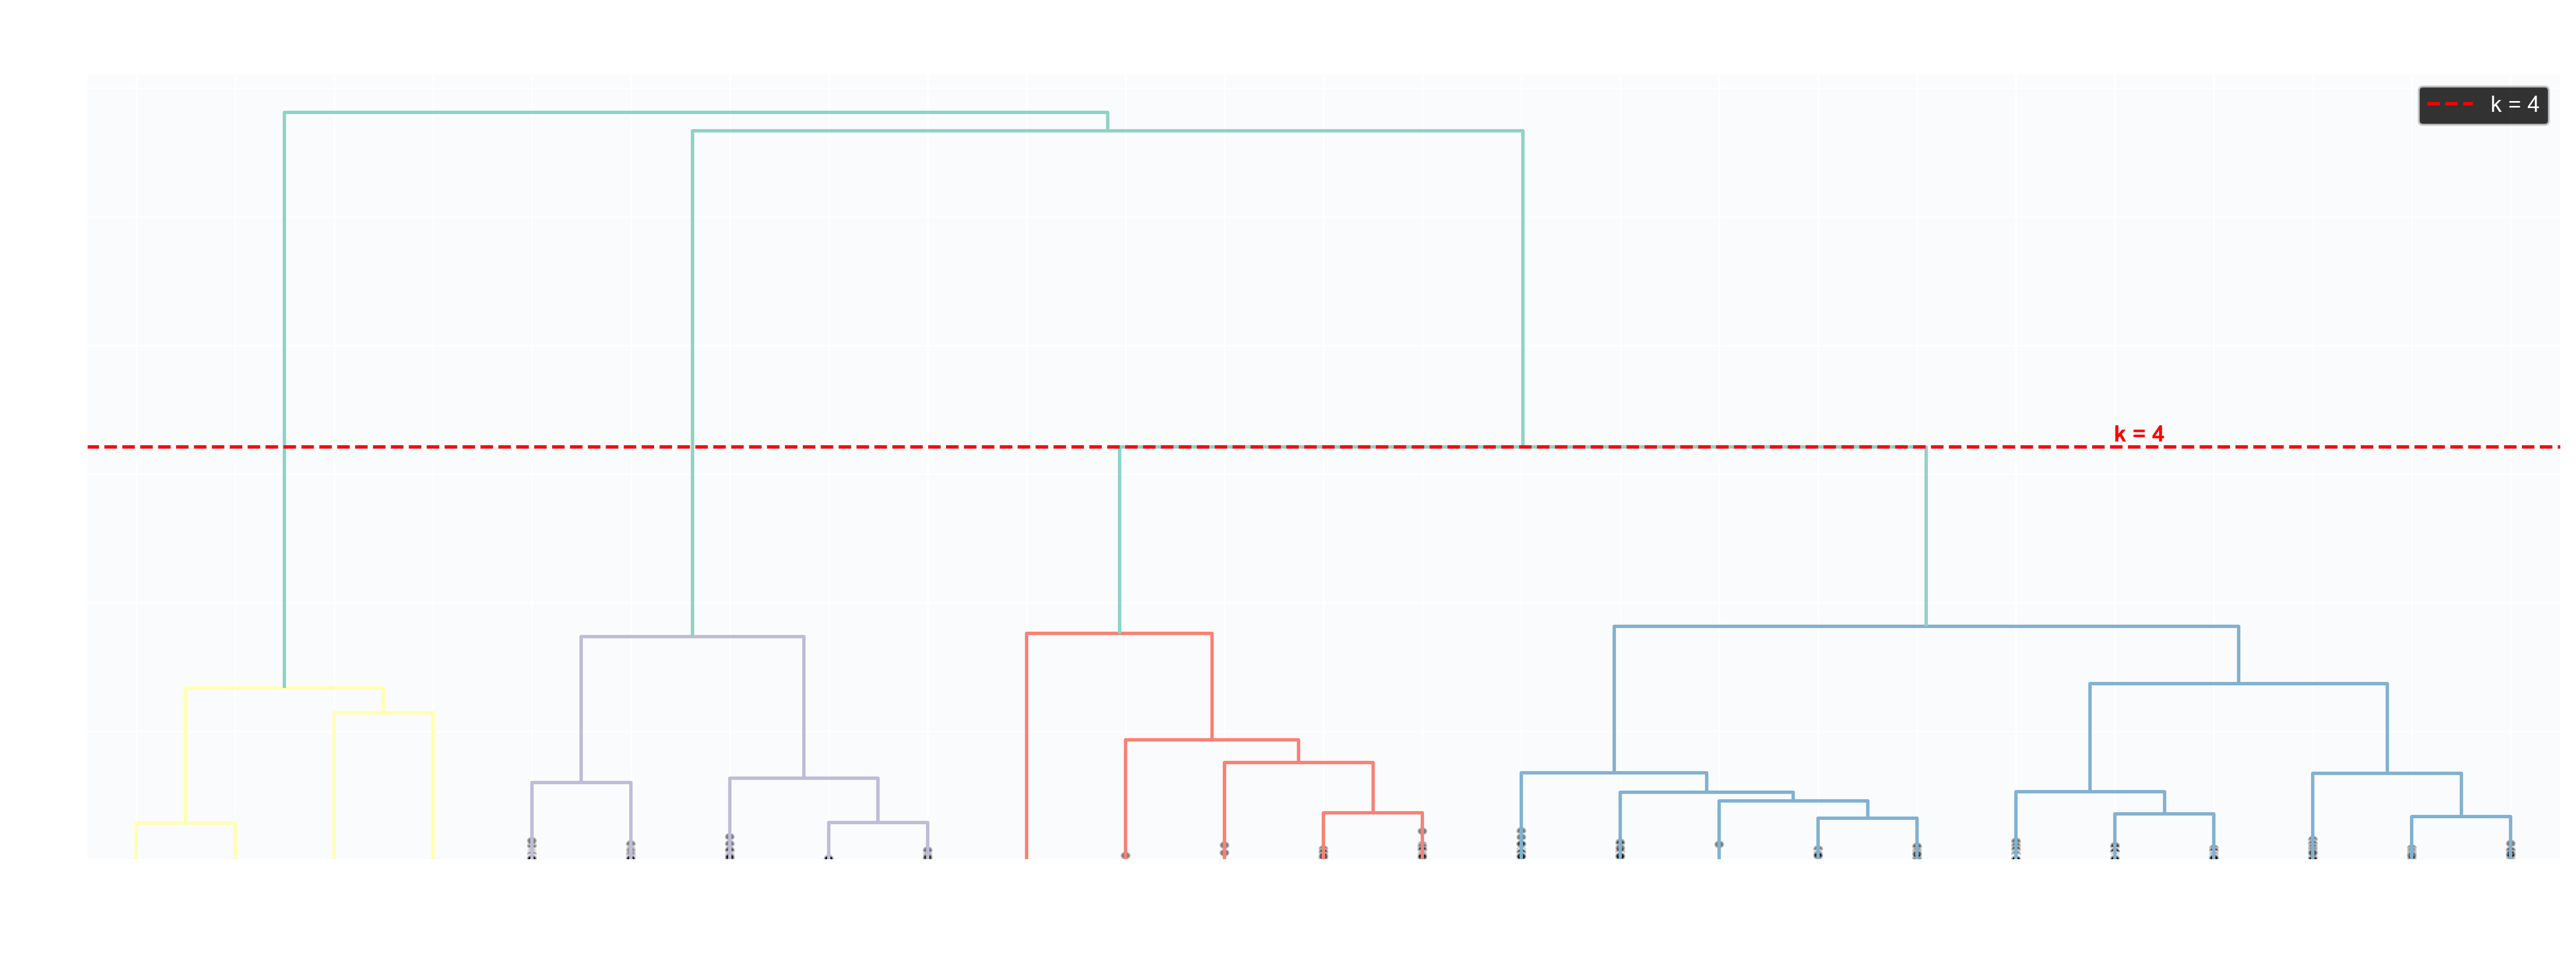

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
from IPython.display import display, Image
import matplotlib.pyplot as plt

# =========================================================
# XÂY DỰNG DENDROGRAM
# =========================================================
# Dendrogram dùng để trực quan hóa quá trình gộp cụm
# Trong phần này chỉ lấy mẫu dữ liệu để biểu đồ dễ đọc hơn

# Lấy tối đa 500 khách hàng để vẽ dendrogram
sample_size = min(500, len(rfm))

sample = rfm[
    ["recency", "frequency", "monetary"]
].sample(
    n=sample_size,
    random_state=42
)

# Chuẩn hóa mẫu bằng scaler đã fit từ toàn bộ dữ liệu RFM
sample_scaled = scaler.transform(sample)

# Tạo ma trận linkage cho Hierarchical Clustering
# Ward linkage: gộp cụm sao cho phương sai tăng ít nhất
Z = linkage(
    sample_scaled,
    method="ward"
)

# =========================================================
# TÍNH ĐỘ CAO ĐƯỜNG CẮT CHO k CỤM
# =========================================================
# cut_height là khoảng cách tại đó dendrogram được cắt
# để tạo ra đúng số cụm mong muốn

n_sample = len(sample)

cut_height = float(
    Z[n_sample - n_clusters, 2]
)

# =========================================================
# HIỂN THỊ THÔNG TIN
# =========================================================

print(f"Dendrogram sample size : {sample_size} customers")
print(f"Full clustering dataset: {len(rfm):,} customers")
print(f"Cut height for {n_clusters} clusters: {cut_height:.4f}")

# =========================================================
# VẼ DENDROGRAM
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 6),
    facecolor="white"
)

ax.set_facecolor("#fafbfc")

dendrogram(
    Z,

    # Chỉ hiển thị các nhánh cuối để biểu đồ gọn hơn
    truncate_mode="lastp",
    p=25,

    ax=ax,
    leaf_font_size=8,
    show_contracted=True,

    # Tô màu các cụm theo đường cắt
    color_threshold=cut_height,
)

# =========================================================
# VẼ ĐƯỜNG CẮT ĐỂ TẠO k CỤM
# =========================================================

ax.axhline(
    y=cut_height,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"k = {n_clusters}"
)

# Ghi chú số cụm trên biểu đồ
_, max_x = ax.get_xlim()

ax.annotate(
    f"k = {n_clusters}",
    xy=(max_x, cut_height),
    xytext=(max_x - 40, cut_height + 0.2),
    fontsize=10,
    fontweight="bold",
    color="red",
    ha="right",
)

# =========================================================
# TIÊU ĐỀ VÀ NHÃN TRỤC
# =========================================================

ax.set_title(
    "Dendrogram - Hierarchical Clustering (Ward Linkage)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Customer Groups")
ax.set_ylabel("Euclidean Distance")

# =========================================================
# TINH CHỈNH GIAO DIỆN BIỂU ĐỒ
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()

# =========================================================
# LƯU VÀ HIỂN THỊ BIỂU ĐỒ
# =========================================================

plt.savefig(
    "dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Hiển thị lại ảnh trong một số môi trường như PyCharm/Jupyter
display(Image(filename="dendrogram.png", width=1000))

## 8. Đánh giá Silhouette Score

Silhouette Score đo định lượng chất lượng phân cụm. Với mỗi khách hàng:

    s(i) = (b(i) - a(i)) / max(a(i), b(i))

- `a(i)`: khoảng cách trung bình đến các điểm cùng cụm
- `b(i)`: khoảng cách trung bình đến cụm gần nhất

Kết quả: từ -1 (phân cụm sai) đến +1 (phân cụm tốt). Giá trị > 0.5 → cấu trúc cụm hợp lý.

Tính toán trên **toàn bộ** dữ liệu đã chuẩn hóa.

In [19]:
# =========================================================
# ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM
# BẰNG SILHOUETTE SCORE
# =========================================================
# Silhouette Score đo mức độ:
# - các điểm dữ liệu giống cụm của chính nó
# - và khác biệt với các cụm khác
#
# Giá trị nằm trong khoảng:
# -1 → 1
#
# Gần 1  : phân cụm tốt
# Gần 0  : các cụm chồng lấn
# < 0    : phân cụm sai

from sklearn.metrics import silhouette_score, silhouette_samples

# =========================================================
# TÍNH SILHOUETTE SCORE TOÀN BỘ DATASET
# =========================================================
# Input:
# - rfm_scaled      : dữ liệu RFM đã chuẩn hóa
# - rfm["cluster"]  : nhãn cụm sau khi clustering

sil = silhouette_score(
    rfm_scaled,
    rfm["cluster"]
)

# =========================================================
# HIỂN THỊ KẾT QUẢ
# =========================================================

print("=" * 50)

print(f"Silhouette Score: {sil:.4f}")

print("=" * 50)

# =========================================================
# DIỄN GIẢI Ý NGHĨA SILHOUETTE SCORE
# =========================================================

if sil >= 0.71:

    # Cấu trúc cụm rất rõ ràng
    print("Strong structure")

elif sil >= 0.51:

    # Phân cụm tốt, các cụm tách biệt khá rõ
    print("Good clustering quality")

elif sil >= 0.26:

    # Có cấu trúc cụm nhưng vẫn còn overlap
    print("Moderate structure")

else:

    # Cụm yếu hoặc không có cấu trúc rõ ràng
    print("Weak / No structure")

Silhouette Score: 0.6161
Good clustering quality


## 9. Trực quan hóa 3D — Plotly

Gán tên phân khúc cho mỗi cụm dựa trên so sánh hồ sơ RFM trung bình với đặc điểm khách hàng kỳ vọng:

| Phân khúc | Tiêu chí gán | Đặc điểm |
|---|---|---|
| **VIP Customers** | Thấp R + cao F + cao M | Mua gần đây, tần suất cao, chi tiêu lớn |
| **Loyal Customers** | Cao F trong số còn lại | Tần suất mua cao, recency vừa phải |
| **New Customers** | Phần còn lại sau khi gán VIP/Loyal/Lost | Mua gần đây, tần suất thấp |
| **Lost Customers** | Cao R + thấp F + thấp M | Ngừng mua lâu, ít mua, chi tiêu thấp |

Gán nhãn theo phương pháp greedy scoring — khớp từng cụm với nhãn phù hợp nhất.

In [10]:
# =========================================================
# GÁN TÊN BUSINESS CHO TỪNG CLUSTER
# =========================================================
# Sau khi mô hình tạo ra các cluster dạng số: 0, 1, 2, 3
# Ta cần chuyển chúng thành các nhóm khách hàng dễ hiểu về mặt kinh doanh

# Bảng màu cố định cho từng nhóm khách hàng
cluster_meta = {
    "VIP Customers":   {"color": "#6366f1"},
    "Loyal Customers": {"color": "#a855f7"},
    "New Customers":   {"color": "#06b6d4"},
    "Lost Customers":  {"color": "#f59e0b"},
}


def _label_clusters(rfm_df, labels):

    # =====================================================
    # TÍNH PROFILE TRUNG BÌNH CỦA TỪNG CLUSTER
    # =====================================================
    # mean_r: Recency trung bình
    # mean_f: Frequency trung bình
    # mean_m: Monetary trung bình

    profiles = rfm_df.copy()
    profiles["cluster"] = labels

    summary = profiles.groupby("cluster").agg(
        mean_r=("recency", "mean"),
        mean_f=("frequency", "mean"),
        mean_m=("monetary", "mean"),
    )

    mapping = {}
    available = set(summary.index.tolist())

    # =====================================================
    # GÁN NHÃN VIP CUSTOMERS
    # =====================================================
    # VIP là nhóm có:
    # - Recency thấp  : mua gần đây
    # - Frequency cao : mua thường xuyên
    # - Monetary cao  : chi tiêu nhiều

    if available:
        vip_score = (
            -summary["mean_r"]
            + summary["mean_f"]
            + summary["mean_m"]
        )

        best = vip_score.idxmax()
        mapping[best] = "VIP Customers"
        available.remove(best)

    # =====================================================
    # GÁN NHÃN LOST CUSTOMERS
    # =====================================================
    # Lost là nhóm có:
    # - Recency cao   : lâu rồi chưa mua
    # - Frequency thấp
    # - Monetary thấp

    if available:
        remaining = summary[
            summary.index.isin(available)
        ]

        lost_score = (
            remaining["mean_r"]
            - remaining["mean_f"]
            - remaining["mean_m"]
        )

        worst = lost_score.idxmax()
        mapping[worst] = "Lost Customers"
        available.remove(worst)

    # =====================================================
    # GÁN NHÃN LOYAL CUSTOMERS
    # =====================================================
    # Loyal là nhóm còn lại có Frequency cao nhất
    # Tức là nhóm khách mua lặp lại nhiều lần

    if available:
        remaining = summary[
            summary.index.isin(available)
        ]

        loyal = remaining["mean_f"].idxmax()
        mapping[loyal] = "Loyal Customers"
        available.remove(loyal)

    # =====================================================
    # GÁN NHÃN NEW CUSTOMERS
    # =====================================================
    # Nhóm còn lại được xem là New Customers

    for idx in available:
        mapping[idx] = "New Customers"

    return mapping


# =========================================================
# ÁP DỤNG NHÃN BUSINESS VÀO BẢNG RFM
# =========================================================

label_map = _label_clusters(
    rfm,
    rfm["cluster"]
)

# Map cluster số sang segment business
rfm["segment"] = rfm["cluster"].map(label_map)

# Gán màu cho từng segment để trực quan hóa nhất quán
rfm["color"] = rfm["segment"].map(
    lambda s: cluster_meta[s]["color"]
)

# =========================================================
# HIỂN THỊ KẾT QUẢ GÁN NHÃN
# =========================================================

print("Cluster-to-segment mapping:")

for k, v in label_map.items():
    print(f"  Cluster {k} -> {v}")

print()

# In profile trung bình của từng segment
for seg in sorted(rfm["segment"].unique()):

    sub = rfm[
        rfm["segment"] == seg
    ]

    print(
        f"  {seg:15s}: "
        f"{len(sub):>6} customers  "
        f"(R={sub['recency'].mean():6.1f}, "
        f"F={sub['frequency'].mean():5.1f}, "
        f"M=${sub['monetary'].mean():>10.2f})"
    )

Cluster-to-segment mapping:
  Cluster 0 -> VIP Customers
  Cluster 2 -> Lost Customers
  Cluster 3 -> Loyal Customers
  Cluster 1 -> New Customers

  Lost Customers :    946 customers  (R= 259.9, F=  1.5, M=$    338.90)
  Loyal Customers:    144 customers  (R=  12.7, F= 24.0, M=$   9765.10)
  New Customers  :   3228 customers  (R=  47.5, F=  3.8, M=$   1039.89)
  VIP Customers  :     20 customers  (R=  22.0, F= 71.2, M=$  78516.70)


In [18]:
# Interactive 3D scatter plot
# Subsample to 1500 points for responsive notebook rendering
plot_n = min(len(rfm), 1500)
plot_sample = rfm.sample(n=plot_n, random_state=42)

fig = px.scatter_3d(
    plot_sample,
    x="recency", y="frequency", z="monetary",
    color="segment",
    color_discrete_map={s: cluster_meta[s]["color"] for s in cluster_meta},
    title="3D RFM Customer Segmentation",
    labels={"color": "Segment"},
    opacity=0.75,
)
# marker=dict(size=...) for plotly 6.x compatibility
fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(
        xaxis_title="Recency (days)",
        yaxis_title="Frequency (orders)",
        zaxis_title="Monetary ($)",
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    height=600,
)
fig.show()

## 10. So sánh với K-Means

Để đánh giá chất lượng phân cụm Hierarchical Clustering (Ward Linkage),
thực hiện so sánh với thuật toán K-Means — một phương pháp phân cụm
phổ biến nhất làm baseline.

Hai thuật toán được so sánh trên cùng điều kiện:

| Tiêu chí              | Giá trị                  |
|-----------------------|--------------------------|
| Dữ liệu đầu vào       | RFM đã chuẩn hóa (Z-score) |
| Số cụm                | k = 4                    |
| Hàm đánh giá          | Silhouette Score         |

Kết quả cho thấy Hierarchical Clustering có thực sự hiệu quả hơn so với
K-Means trên bộ dữ liệu RFM này.

In [33]:
# =========================================================
# CHẠY K-MEANS TRÊN DỮ LIỆU RFM ĐÃ CHUẨN HÓA
# =========================================================
# Sử dụng cùng dữ liệu và cùng số cụm với Hierarchical
# để so sánh công bằng giữa hai thuật toán

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init='auto',
)

# Gán nhãn cụm K-Means
rfm["cluster_km"] = kmeans.fit_predict(rfm_scaled)

# =========================================================
# TÍNH SILHOUETTE SCORE CHO CẢ HAI THUẬT TOÁN
# =========================================================

from sklearn.metrics import silhouette_score

# Hierarchical Clustering (đã tính ở phần 8)
sil_hierarchical = silhouette_score(
    rfm_scaled,
    rfm["cluster"]
)

# K-Means
sil_kmeans = silhouette_score(
    rfm_scaled,
    rfm["cluster_km"]
)

# =========================================================
# HIỂN THỊ KẾT QUẢ
# =========================================================

print("=" * 60)
print(" SO SÁNH CHẤT LƯỢNG PHÂN CỤM")
print("=" * 60)
print()
print(f"  Hierarchical (Ward): {sil_hierarchical:.4f}")
print(f"  K-Means:             {sil_kmeans:.4f}")
print()

# Tính chênh lệch giữa hai thuật toán
diff = sil_hierarchical - sil_kmeans

if diff > 0:
    print(f"  => Hierarchical Clustering cao hơn {diff:.4f}")
else:
    print(f"  => K-Means cao hơn {abs(diff):.4f}")

print("=" * 60)

 SO SÁNH CHẤT LƯỢNG PHÂN CỤM

  Hierarchical (Ward): 0.6161
  K-Means:             0.6182

  => K-Means cao hơn 0.0020


In [34]:
# =========================================================
# BẢNG SO SÁNH KẾT QUẢ GIỮA HAI THUẬT TOÁN
# =========================================================

comparison = pd.DataFrame({
    "Thuật toán": [
        "Hierarchical (Ward)",
        "K-Means",
    ],
    "Số cụm": [4, 4],
    "Silhouette Score": [sil_hierarchical, sil_kmeans],
})

# Tô màu xanh cho cột có giá trị cao nhất
comparison = comparison.style.highlight_max(
    subset=["Silhouette Score"],
    color="#d4edda",
)

comparison

,Thuật toán,Số cụm,Silhouette Score
0,Hierarchical (Ward),4,0.616144
1,K-Means,4,0.618161


In [36]:
# =========================================================
# BIỂU ĐỒ CỘT SO SÁNH SILHOUETTE SCORE
# =========================================================

fig, ax = plt.subplots(figsize=(7, 4.5))

algorithms = ["Hierarchical\n(Ward)", "K-Means"]
scores = [sil_hierarchical, sil_kmeans]
bar_colors = ["#6366f1", "#a855f7"]

bars = ax.bar(
    algorithms,
    scores,
    color=bar_colors,
    width=0.45,
    edgecolor="white",
    linewidth=0,
    alpha=0.9,
)

# Hiển thị giá trị trên đầu mỗi cột
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=13,
        color="#333",
    )

# Tinh chỉnh giao diện biểu đồ
ax.set_ylabel("Silhouette Score", fontsize=12, fontweight="bold")
ax.set_title(
    "So sánh chất lượng phân cụm",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_ylim(0, max(scores) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
# =========================================================
# KẾT LUẬN TỪ THỰC NGHIỆM SO SÁNH
# =========================================================
# Ngưỡng chênh lệch: nếu |diff| < 0.02 => coi là tương đương

print("=" * 65)
print(" KẾT LUẬN SO SÁNH")
print("=" * 65)

abs_diff = abs(diff)

if abs_diff < 0.02:

    # Hai thuật toán có chất lượng phân cụm tương đương
    if diff < 0:
        # K-Means nhỉnh hơn một chút
        print()
        print("""
KẾT LUẬN:

K-Means và Hierarchical Clustering đều cho chất lượng phân cụm
tương đương trên bộ dữ liệu RFM.

Mặc dù K-Means đạt Silhouette Score nhỉnh hơn một chút, mức
chênh lệch là không đáng kể.

Trong đề tài này, Hierarchical Clustering vẫn được lựa chọn vì:

  * Hỗ trợ dendrogram để phân tích cấu trúc dữ liệu
  * Không cần xác định số cụm ngay từ đầu
  * Có khả năng diễn giải cao
  * Thể hiện được cấu trúc phân cấp giữa các nhóm khách hàng

Do đó, Hierarchical Clustering phù hợp hơn với mục tiêu nghiên
cứu và phân tích khách hàng của đề tài.
""")
    else:
        # Hierarchical nhỉnh hơn một chút
        print()
        print("""
KẾT LUẬN:

Hierarchical Clustering và K-Means cho chất lượng phân cụm rất
gần nhau trên bộ dữ liệu RFM.

Hierarchical Clustering đạt Silhouette Score cao hơn một chút,
tuy nhiên mức chênh lệch là không lớn.

Ngoài chất lượng phân cụm, Hierarchical Clustering còn có
các ưu điểm:

  * Hỗ trợ dendrogram
  * Dễ diễn giải
  * Thể hiện cấu trúc phân cấp của dữ liệu

Vì vậy đây là thuật toán được lựa chọn trong đề tài.
""")

else:

    # Chênh lệch >= 0.02 => một thuật toán vượt trội
    if diff > 0:
        print()
        print(
            f"Hierarchical Clustering với Ward Linkage vượt trội "
            f"K-Means với chênh lệch Silhouette Score = {abs_diff:.4f} "
            f"(>{0.02})."
        )
        print()
        print(
            "Điều này xác nhận việc lựa chọn Hierarchical Clustering "
            "là phù hợp cho bài toán phân khúc khách hàng. Ngoài chất "
            "lượng phân cụm tốt hơn, phương pháp này còn cung cấp "
            "dendrogram — giúp diễn giải cấu trúc phân cấp dữ liệu "
            "một cách trực quan và có ý nghĩa kinh doanh rõ ràng."
        )
    else:
        print()
        print(
            f"K-Means vượt trội Hierarchical Clustering với chênh lệch "
            f"Silhouette Score = {abs_diff:.4f} (>{0.02})."
        )
        print()
        print(
            "Tuy nhiên, Hierarchical Clustering vẫn được lựa chọn "
            "trong đề tài vì hỗ trợ dendrogram, khả năng diễn giải cao, "
            "và thể hiện cấu trúc phân cấp của dữ liệu — những ưu thế "
            "mà K-Means không có được."
        )

print()
print(
    f"Hierarchical (Ward): {sil_hierarchical:.4f} | "
    f"K-Means: {sil_kmeans:.4f} | "
    f"Chênh lệch: {abs_diff:.4f}"
)
print("=" * 65)

 KẾT LUẬN SO SÁNH


KẾT LUẬN:

K-Means và Hierarchical Clustering đều cho chất lượng phân cụm
tương đương trên bộ dữ liệu RFM.

Mặc dù K-Means đạt Silhouette Score nhỉnh hơn một chút, mức
chênh lệch là không đáng kể.

Trong đề tài này, Hierarchical Clustering vẫn được lựa chọn vì:

  * Hỗ trợ dendrogram để phân tích cấu trúc dữ liệu
  * Không cần xác định số cụm ngay từ đầu
  * Có khả năng diễn giải cao
  * Thể hiện được cấu trúc phân cấp giữa các nhóm khách hàng

Do đó, Hierarchical Clustering phù hợp hơn với mục tiêu nghiên
cứu và phân tích khách hàng của đề tài.


Hierarchical (Ward): 0.6161 | K-Means: 0.6182 | Chênh lệch: 0.0020


## 11. Diễn giải ý nghĩa kinh doanh



Tổng hợp kết quả phân cụm: bảng hồ sơ từng phân khúc (đặc điểm RFM trung bình), biểu đồ đóng góp doanh thu, so sánh RFM tương đối giữa các nhóm, và đề xuất chiến lược marketing cho từng phân khúc.

In [11]:
# Per-segment summary table
summary = rfm.groupby("segment").agg(
    customers=("CustomerID", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
).reset_index()
summary["share"] = (summary["customers"] / summary["customers"].sum()
                    * 100).round(1)
summary = summary.sort_values("total_revenue", ascending=False)

print("Segment Profile Summary")
print("=" * 72)
print(f"{'Segment':<18s} {'Cust.':>7s} {'Share':>6s} "
      f"{'Avg R':>7s} {'Avg F':>7s} {'Avg M':>10s} {'Revenue':>14s}")
print("-" * 72)
for _, row in summary.iterrows():
    print(f"{row['segment']:<18s} {row['customers']:>7,d} "
          f"{row['share']:>5.1f}% "
          f"{row['avg_recency']:>7.1f} {row['avg_frequency']:>7.1f} "
          f"${row['avg_monetary']:>9.2f} "
          f"${row['total_revenue']:>13,.2f}")
print("=" * 72)

Segment Profile Summary
Segment              Cust.  Share   Avg R   Avg F      Avg M        Revenue
------------------------------------------------------------------------
New Customers        3,228  74.4%    47.5     3.8 $  1039.89 $ 3,356,751.21
VIP Customers           20   0.5%    22.0    71.2 $ 78516.70 $ 1,570,334.10
Loyal Customers        144   3.3%    12.7    24.0 $  9765.10 $ 1,406,174.47
Lost Customers         946  21.8%   259.9     1.5 $   338.90 $   320,596.75


In [15]:
# Revenue contribution pie chart + normalized RFM bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

names = summary["segment"].tolist()
revenues = summary["total_revenue"].tolist()
colors_list = [cluster_meta[n]["color"] for n in names]

# Pie chart: revenue share by segment
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    revenues, labels=names, colors=colors_list,
    autopct="%1.1f%%", startangle=140,
    textprops={"fontsize": 10},
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_color("white")
ax.set_title("Revenue Contribution by Segment",
             fontsize=12, fontweight="bold", pad=12)

# Bar chart: relative RFM profile per segment (normalized for comparison)
ax = axes[1]
x = np.arange(len(names))
w = 0.25
ax.bar(x - w, summary["avg_recency"] / summary["avg_recency"].max(),
       w, label="Avg Recency", color="#6366f1", alpha=0.85)
ax.bar(x, summary["avg_frequency"] / summary["avg_frequency"].max(),
       w, label="Avg Frequency", color="#a855f7", alpha=0.85)
ax.bar(x + w, summary["avg_monetary"] / summary["avg_monetary"].max(),
       w, label="Avg Monetary", color="#06b6d4", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Normalized Value", fontsize=10)
ax.set_title("Relative RFM Profile per Segment",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
# Actionable recommendations per segment
recommendations = {
    "VIP Customers": [
        "Launch exclusive loyalty program with tiered rewards",
        "Provide early access to new products and limited editions",
        "Assign dedicated account managers for top spenders",
        "Create referral program leveraging brand influence",
    ],
    "Loyal Customers": [
        "Upsell premium product lines to increase average order value",
        "Implement tiered rewards to encourage promotion to VIP",
        "Send personalized recommendations based on purchase history",
        "Offer bundled deals to increase basket size",
    ],
    "New Customers": [
        "Send welcome series with onboarding product guides",
        "Offer first-repeat-purchase discount within 30 days",
        "Collect preferences through post-purchase surveys",
        "Enroll in nurture campaign to build repeat habits",
    ],
    "Lost Customers": [
        "Deploy win-back email campaign with personalized offers",
        "Conduct exit surveys to understand churn reasons",
        "Offer time-limited comeback incentives",
        "Analyze last purchase date to prioritize outreach urgency",
    ],
}

print("=" * 65)
print(" BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 65)

for seg in ["VIP Customers", "Loyal Customers",
            "New Customers", "Lost Customers"]:
    if seg not in rfm["segment"].values:
        continue
    sub = rfm[rfm["segment"] == seg]
    pct = len(sub) / len(rfm) * 100
    print()
    print(f"> {seg} ({len(sub):,} customers, {pct:.1f}% of base)")
    print(f"  Avg Recency: {sub['recency'].mean():.1f} days | "
          f"Avg Frequency: {sub['frequency'].mean():.1f} orders | "
          f"Avg Monetary: ${sub['monetary'].mean():.2f}")
    for rec in recommendations[seg]:
        print(f"  * {rec}")

print()
print("=" * 65)
print(f" Silhouette Score: {sil:.4f}  |  Clusters: {n_clusters}")
print("=" * 65)

 BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT

> VIP Customers (20 customers, 0.5% of base)
  Avg Recency: 22.0 days | Avg Frequency: 71.2 orders | Avg Monetary: $78516.70
  * Launch exclusive loyalty program with tiered rewards
  * Provide early access to new products and limited editions
  * Assign dedicated account managers for top spenders
  * Create referral program leveraging brand influence

> Loyal Customers (144 customers, 3.3% of base)
  Avg Recency: 12.7 days | Avg Frequency: 24.0 orders | Avg Monetary: $9765.10
  * Upsell premium product lines to increase average order value
  * Implement tiered rewards to encourage promotion to VIP
  * Send personalized recommendations based on purchase history
  * Offer bundled deals to increase basket size

> New Customers (3,228 customers, 74.4% of base)
  Avg Recency: 47.5 days | Avg Frequency: 3.8 orders | Avg Monetary: $1039.89
  * Send welcome series with onboarding product guides
  * Offer first-repeat-purchase discount within 30 d